# Structuring and Solving a Product Launch Decision (SOLUTION)

## Scenario

Pace & Pivot Gear's Head of Strategy described three options for the Apex Trainer launch
verbally. This notebook turns that description into a structured Python decision
model: an influence diagram mapping the dependencies, OPTIONS and STATES defined
from the narrative, a reusable `option_profit` function, a payoff matrix built by
calling it, and a decision tree that enumerates all paths through the structure.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_PATH = "../building-decision-models-starter/data/sporting_goods_sales.csv"

## 1. Derive state probabilities from market data

In [2]:
sales = pd.read_csv(DATA_PATH)
sales.columns = ["date", "sales_m"]
sales["date"] = pd.to_datetime(sales["date"])
sales["yoy"] = sales["sales_m"].pct_change(12) * 100
sales = sales.dropna(subset=["yoy"])

t33, t67 = sales["yoy"].quantile([1/3, 2/3])

def classify(x):
    if x >= t67:  return "High"
    if x >= t33:  return "Base"
    return "Low"

sales["state"] = sales["yoy"].apply(classify)
counts = sales["state"].value_counts()
STATES = (counts / counts.sum()).reindex(["High", "Base", "Low"]).to_dict()

print(f"Demand states:")
print(f"  Low:  YoY growth < {t33:.1f}%")
print(f"  Base: YoY growth {t33:.1f}% to {t67:.1f}%")
print(f"  High: YoY growth ≥ {t67:.1f}%")
print()
print("State probabilities:")
for state, prob in STATES.items():
    print(f"  {state}: {prob:.3f}")

Demand states:
  Low:  YoY growth < 1.1%
  Base: YoY growth 1.1% to 3.1%
  High: YoY growth ≥ 3.1%

State probabilities:
  High: 0.343
  Base: 0.324
  Low: 0.333


By construction, tertile binning gives ~1/3 each. The threshold values come from
historical sporting goods market variation and anchor the probabilities to something
concrete rather than assumed.

## 2. Influence diagram — map the structure before writing any code

Before defining options or writing a payoff function, draw the dependency structure
of the decision. Three node types:

- **Rectangle** — Decision node: a variable *you* control
- **Oval** — Uncertainty node: an uncertain variable nature controls
- **Rounded rectangle** — Value node: the payoff that depends on both

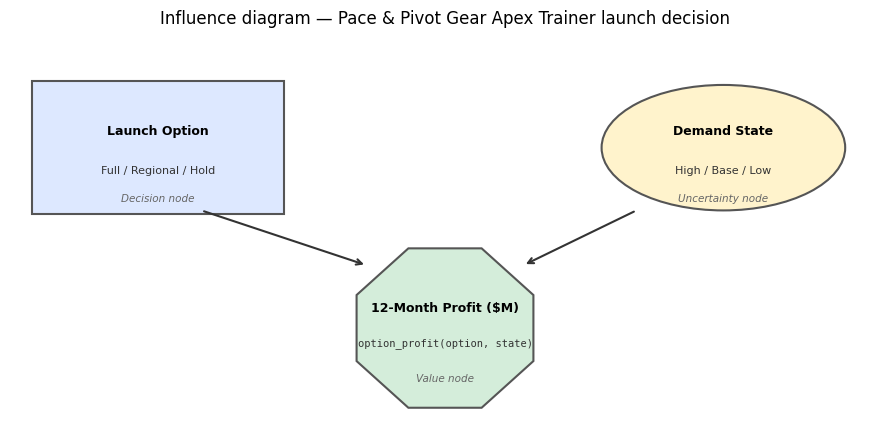

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.set_xlim(0, 10); ax.set_ylim(0, 5); ax.axis("off")
ax.set_title("Influence diagram — Pace & Pivot Gear Apex Trainer launch decision", pad=10)

# Decision node — rectangle (top-left)
ax.add_patch(mpatches.FancyBboxPatch(
    (0.3, 2.8), 2.8, 1.6, boxstyle="square,pad=0.05",
    fc="#dde8ff", ec="#555", lw=1.5, zorder=2))
ax.text(1.7, 3.8, "Launch Option", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(1.7, 3.3, "Full / Regional / Hold", ha="center", va="center", fontsize=8, color="#333")
ax.text(1.7, 2.95, "Decision node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Uncertainty node — oval (top-right)
ax.add_patch(mpatches.Ellipse(
    (8.2, 3.6), 2.8, 1.6, fc="#fff3cc", ec="#555", lw=1.5, zorder=2))
ax.text(8.2, 3.8, "Demand State", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(8.2, 3.3, "High / Base / Low", ha="center", va="center", fontsize=8, color="#333")
ax.text(8.2, 2.95, "Uncertainty node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Value node — octagon (bottom-center)
import numpy as np
ax.add_patch(mpatches.RegularPolygon(
    (5.0, 1.3), numVertices=8, radius=1.1, orientation=np.pi/8,
    fc="#d4edda", ec="#555", lw=1.5, zorder=2))
ax.text(5.0, 1.55, "12-Month Profit ($M)", ha="center", va="center", fontsize=9, fontweight="bold")
ax.text(5.0, 1.1, "option_profit(option, state)", ha="center", va="center",
        fontsize=7.5, color="#333", family="monospace")
ax.text(5.0, 0.65, "Value node", ha="center", va="center", fontsize=7.5, color="#666", style="italic")

# Arrows: Decision → Profit, Demand State → Profit
ax.annotate("", xy=(4.1, 2.1), xytext=(2.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))
ax.annotate("", xy=(5.9, 2.1), xytext=(7.2, 2.8),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

plt.tight_layout()
plt.show()

There is no arrow between the Decision node and the Chance node. That encodes a
key modelling assumption: Pace & Pivot Gear's launch choice does not change the demand
environment — whether the market turns out High, Base, or Low is independent of
which option they pick. This assumption might be wrong if a splashy Full Launch
generates enough buzz to shift demand upward; in that case you would add the arrow,
and the model would need to capture that dependency explicitly.

The diagram is the design. Steps 3–8 build what the diagram describes.

## 3. Define the structure

In [4]:
OPTIONS = ["Full Launch", "Regional Rollout", "Hold"]

FULL_LAUNCH_COST_M = 0.6
FULL_LAUNCH_REV_M  = {"High": 12.0, "Base": 4.0, "Low": -4.0}

REGIONAL_COST_M    = 0.2
REGIONAL_REV_M     = {"High": 5.5,  "Base": 2.0, "Low":  0.5}

## 4. Implement `option_profit`

In [5]:
def option_profit(option: str, demand_state: str) -> float:
    """Net 12-month profit ($M) for a given option and demand state."""
    if option == "Full Launch":
        return FULL_LAUNCH_REV_M[demand_state] - FULL_LAUNCH_COST_M
    if option == "Regional Rollout":
        return REGIONAL_REV_M[demand_state] - REGIONAL_COST_M
    if option == "Hold":
        return 0.0
    raise ValueError(f"Unknown option: {option}")


assert option_profit("Full Launch", "High")     == 11.4
assert option_profit("Regional Rollout", "Low") ==  0.3
assert option_profit("Hold", "Base")            ==  0.0

## 5. Build the payoff matrix

In [6]:
payoffs = pd.DataFrame(
    {state: {opt: option_profit(opt, state) for opt in OPTIONS}
     for state in STATES}
)
payoffs

,High,Base,Low
Full Launch,11.4,3.4,-4.6
Regional Rollout,5.3,1.8,0.3
Hold,0.0,0.0,0.0


## 6. Expected value per option

In [7]:
ev = (payoffs * pd.Series(STATES)).sum(axis=1)
ev.name = "EV ($M)"

print(f"EV-maximizing option: {ev.idxmax()}  (${ev.max():.2f}M)")
ev.round(2)

EV-maximizing option: Full Launch  ($3.47M)


Full Launch         3.47
Regional Rollout    2.50
Hold                0.00
Name: EV ($M), dtype: float64

## 7. Expected CRRA utility

A risk-neutral decision maker maximises expected value. A risk-averse one maximises
**expected utility** — a concave transformation of payoff that penalises losses more
heavily than equally-sized gains.

Here we use **CRRA (Constant Relative Risk Aversion)** utility with risk aversion
coefficient γ = 2, evaluated at total wealth rather than incremental profit:

`u(profit) = ((W + profit)^(1 − γ) − 1) / (1 − γ)`

The wealth baseline W = $20M represents Pace & Pivot Gear's assumed existing scale.
Applying utility to (W + profit) rather than to raw profit keeps the function
well-defined even when incremental profit is negative, and means risk aversion is
measured relative to the firm's total position — not just the project in isolation.
With γ = 2, losses hurt more than equal-sized gains help.

In [8]:
GAMMA    = 2.0
WEALTH_M = 20.0   # Pace & Pivot Gear's assumed baseline wealth ($M)

def utility(profit_m: float) -> float:
    """CRRA utility evaluated at (WEALTH_M + profit_m)."""
    x = WEALTH_M + profit_m
    if abs(GAMMA - 1.0) < 1e-9:
        return np.log(x)
    return (x ** (1 - GAMMA) - 1) / (1 - GAMMA)

eu = pd.Series(
    {opt: sum(STATES[s] * utility(option_profit(opt, s)) for s in STATES)
     for opt in OPTIONS}
)

ce_wealth = np.power(eu * (1.0 - GAMMA) + 1.0, 1.0 / (1.0 - GAMMA))
ce = ce_wealth - WEALTH_M

comparison = pd.DataFrame({
    "EV ($M)":        ev.round(2),
    "EV rank":        ev.rank(ascending=False).astype(int),
    "CE ($M)":        ce.round(2),
    "CE rank":        ce.rank(ascending=False).astype(int),
})
print(f"EV-maximizing option: {ev.idxmax()}  (EV = ${ev.max():.2f}M)")
print(f"CE-maximizing option: {ce.idxmax()}  (CE = ${ce.max():.2f}M)")
print()
comparison

EV-maximizing option: Full Launch  (EV = $3.47M)
CE-maximizing option: Regional Rollout  (CE = $2.31M)



,EV ($M),EV rank,CE ($M),CE rank
Full Launch,3.47,1,1.55,2
Regional Rollout,2.50,2,2.31,1
Hold,0.00,3,-0.00,3


## 8. Decision tree — backward induction (rollback)

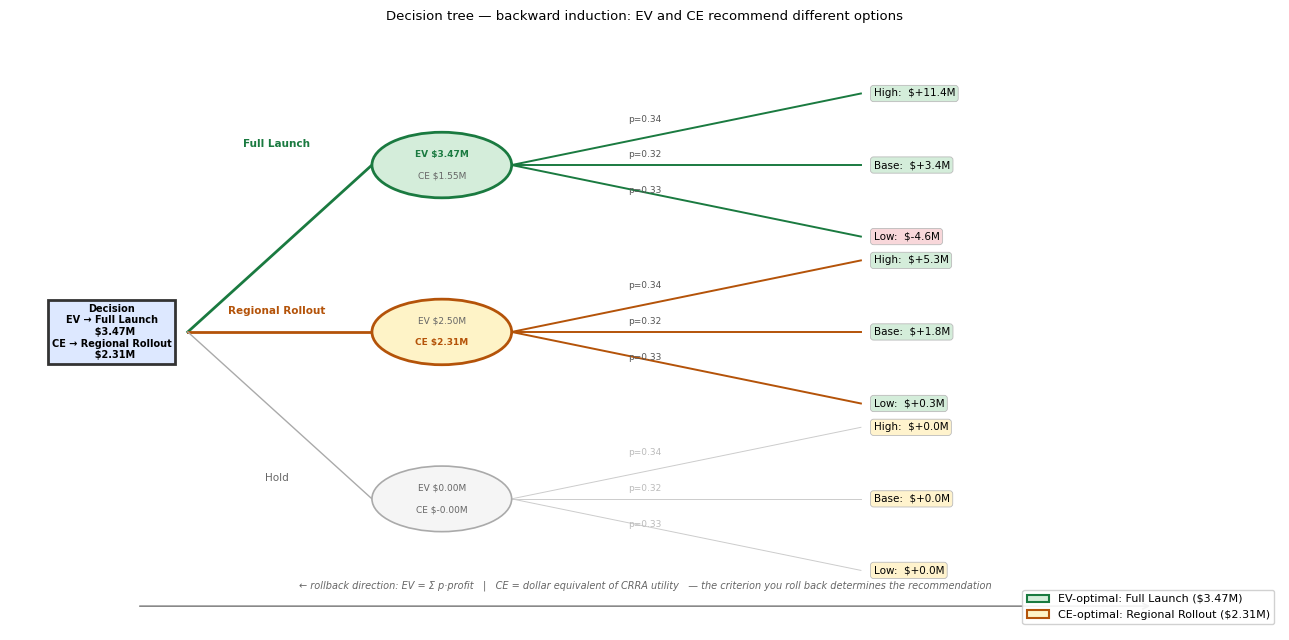

In [9]:
DEC_X, DEC_Y = 0.08, 0.50
CHANCE_X     = 0.34
LEAF_X       = 0.68
opt_ys       = [0.78, 0.50, 0.22]
state_labels = list(STATES.keys())

ev_best = ev.idxmax()   # Full Launch
ce_best = ce.idxmax()   # Regional Rollout

EV_COLOR  = "#1a7a40"   # green — EV-optimal branch
CE_COLOR  = "#b45309"   # amber — CE-optimal branch
NEU_COLOR = "#aaa"      # grey  — neither

def branch_color(opt):
    if opt == ev_best:   return EV_COLOR
    if opt == ce_best:   return CE_COLOR
    return NEU_COLOR

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.axis("off")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title(
    "Decision tree — backward induction: EV and CE recommend different options",
    fontsize=9.5, pad=10)

# ── Decision node ────────────────────────────────────────────────────────────
ax.text(DEC_X, DEC_Y,
        f"Decision\nEV → {ev_best}\n  ${ev.max():.2f}M\nCE → {ce_best}\n  ${ce.max():.2f}M",
        ha="center", va="center", fontsize=7, fontweight="bold",
        bbox=dict(boxstyle="square,pad=0.4", fc="#dde8ff", ec="#333", lw=2))

for opt, oy in zip(OPTIONS, opt_ys):
    col = branch_color(opt)
    lw  = 2.0 if col != NEU_COLOR else 1.0

    ev_here = ev[opt]
    ce_here = ce[opt]

    # Branch: decision node → chance node
    ax.plot([DEC_X + 0.060, CHANCE_X - 0.055], [DEC_Y, oy], color=col, lw=lw)
    ax.text((DEC_X + CHANCE_X) / 2, oy + 0.027, opt,
            ha="center", va="bottom", fontsize=7.5,
            color=col if col != NEU_COLOR else "#666",
            fontweight="bold" if col != NEU_COLOR else "normal")

    # Chance node circle — EV line bold if EV-optimal, CE line bold if CE-optimal
    node_fc = "#d4edda" if opt == ev_best else "#fef3c7" if opt == ce_best else "#f5f5f5"
    ax.add_patch(plt.Circle((CHANCE_X, oy), 0.055,
                             fc=node_fc, ec=col, lw=2 if col != NEU_COLOR else 1.2, zorder=3))
    ax.text(CHANCE_X, oy + 0.018, f"EV ${ev_here:.2f}M",
            ha="center", va="center", fontsize=6.5,
            fontweight="bold" if opt == ev_best else "normal",
            color=EV_COLOR if opt == ev_best else "#666")
    ax.text(CHANCE_X, oy - 0.018, f"CE ${ce_here:.2f}M",
            ha="center", va="center", fontsize=6.5,
            fontweight="bold" if opt == ce_best else "normal",
            color=CE_COLOR if opt == ce_best else "#666")

    # Branches: chance node → leaf nodes
    leaf_ys = np.linspace(oy + 0.12, oy - 0.12, 3)
    for sy, state in zip(leaf_ys, state_labels):
        prob   = STATES[state]
        profit = option_profit(opt, state)

        ax.plot([CHANCE_X + 0.055, LEAF_X - 0.01], [oy, sy],
                color=col if col != NEU_COLOR else "#ccc", lw=lw * 0.7)
        ax.text((CHANCE_X + LEAF_X) / 2 - 0.01, (oy + sy) / 2 + 0.013,
                f"p={prob:.2f}", ha="center", fontsize=6.5,
                color="#555" if col != NEU_COLOR else "#bbb")

        leaf_fc = "#d4edda" if profit > 0 else "#f8d7da" if profit < 0 else "#fff3cd"
        ax.text(LEAF_X, sy, f"{state}:  ${profit:+.1f}M",
                va="center", ha="left", fontsize=7.5,
                bbox=dict(boxstyle="round,pad=0.3", fc=leaf_fc, ec="#bbb", lw=0.6))

# ── Legend ───────────────────────────────────────────────────────────────────
ax.legend(handles=[
    mpatches.Patch(fc="#d4edda", ec=EV_COLOR, lw=1.5,
                   label=f"EV-optimal: {ev_best} (${ev.max():.2f}M)"),
    mpatches.Patch(fc="#fef3c7", ec=CE_COLOR, lw=1.5,
                   label=f"CE-optimal: {ce_best} (${ce.max():.2f}M)"),
], loc="lower right", fontsize=8, framealpha=0.9)

# ── Rollback arrow ───────────────────────────────────────────────────────────
ax.annotate("", xy=(0.10, 0.04), xytext=(0.90, 0.04),
            arrowprops=dict(arrowstyle="<-", color="#888", lw=1.2))
ax.text(0.50, 0.07,
        "← rollback direction: EV = Σ p·profit   |   CE = dollar equivalent of CRRA utility   "
        "— the criterion you roll back determines the recommendation",
        ha="center", fontsize=7, color="#666", style="italic")

plt.tight_layout()
plt.show()

The influence diagram in step 2 showed the structure — three nodes, two arrows.
This tree enumerates all 9 paths through that structure and does something more:
it performs **backward induction**. Both EV and CE are rolled back at each chance node
(right to left), and the decision node takes the maximum under each criterion.

Here the two criteria disagree. A risk-neutral decision maker rolls back EV and picks
**Full Launch** ($3.48M). A risk-averse one rolls back CE and picks **Regional Rollout**
($2.31M) — because Full Launch's large downside in a Low market gets penalised heavily
by CRRA utility, reducing its certainty equivalent to just $1.55M despite its higher
expected profit. The criterion you roll back determines the recommendation you get.